# Chess Elo Prediction — v_final

Predicts player Elo from game moves + clock usage.
- Fast original loader (chessv2 method)
- Board-aware features via `chess_features_final.py`
- Regex clock features extracted separately
- Toggleable feature groups
- Time-control filter
- Balanced sample weights
- Train / Val / Test split
- Optional hyperparam search (toggle off once tuned)
- Permutation importance + optional retrain on top-15 features
- Auto-saves LGB models

In [1]:
# pip install chess zstandard lightgbm pandas scikit-learn matplotlib joblib
import io, re, time, os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zstandard as zstd
import lightgbm as lgb

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import randint, uniform
from joblib import Parallel, delayed

from chess_features_final import extract_features_dataframe, compute_elo_sample_weights

print('All imports OK')

All imports OK


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION — edit everything here, nowhere else
# ═══════════════════════════════════════════════════════════════════════════════

DATA_PATH    = "../../data/villads_data/lichess_db_standard_rated_2017-11.pgn.zst"
MAX_GAMES    = 500_000
RANDOM_STATE = 42
N_JOBS       = -1          # -1 = all CPU cores

# ── splits ────────────────────────────────────────────────────────────────────
VAL_SIZE     = 0.10        # fraction of total data for validation
TEST_SIZE    = 0.10        # fraction of total data for test (rest = train)

# ── time-control filter ───────────────────────────────────────────────────────
# Set to None to keep all games, or e.g. 600 to keep only 10-min games.
# Matches the base time in seconds from the TimeControl header (e.g. '600+0').
FILTER_BASE_SECONDS = None   # e.g. 600, 300, 180, 60, None

# ── feature groups — set True/False to include/exclude each block ─────────────
FEATURE_GROUPS = {
    'structure':  True,   # ply count, material, result
    'checks':     True,   # checks given, check density
    'captures':   True,   # first capture, pawn/piece captures, capture density
    'castling':   True,   # castle move number + side (categorical)
    'style':      True,   # consecutive moves, queen early, territory depth,
                          #   promotions, en passant, legal moves on move 5
    'clock':      True,   # avg/std/max time, time pressure, opening pace,
                          #   clock remaining (normalised to game duration)
    'engine':     True,   # ACPL, inaccuracies, mistakes, blunders, blunder density
                          #   (NaN when [%eval] tags absent — imputed by median)
    'meta':       True,   # TimeControl + ECO one-hot
}

# ── model ─────────────────────────────────────────────────────────────────────
LGBM_PARAMS = {
    'n_estimators':      500,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'random_state':      RANDOM_STATE,
    'verbose':           -1,
    'n_jobs':            N_JOBS,
}

# ── reuse saved models (skip training) ─────────────────────────────────────────
LOAD_PRETRAINED_MODELS = False
PRETRAINED_WHITE_PATH  = None  # e.g. "lgb_elo_500000_notes_whiteelo_YYYYMMDD_HHMMSS.txt"
PRETRAINED_BLACK_PATH  = None  # e.g. "lgb_elo_500000_notes_blackelo_YYYYMMDD_HHMMSS.txt"

# ── hyperparam search (toggle off once you've found good values) ───────────────
RUN_HYPERPARAM_SEARCH  = False
HYPERPARAM_N_ITER      = 10       # number of random configs to try
HYPERPARAM_CV_FOLDS    = 3
HYPERPARAM_SEARCH_SPACE = {
    'n_estimators':      randint(200, 1000),
    'learning_rate':     uniform(0.01, 0.15),
    'num_leaves':        randint(31, 127),
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
}

# ── feature importance ─────────────────────────────────────────────────────────
RUN_PERM_IMPORTANCE    = True
FEATURE_IMPORTANCE_METHOD = "gain"  # "gain", "split", or "permutation"
PERM_N_REPEATS         = 5
TOP_N_FEATURES         = 15       # used for optional retrain
RETRAIN_TOP_N          = False     # retrain model using only top-N features

# ── output ────────────────────────────────────────────────────────────────────
VERBOSE_PLOTS          = True
# Model filenames: set a base name; timestamp is appended automatically
MODEL_SAVE_NAME  = f'lgb_elo_{MAX_GAMES}'
MODEL_SAVE_NOTES = 'alltimes_weightsmax8_2'   # describe what's special — change per run
ELO_BINS = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]

# ═══════════════════════════════════════════════════════════════════════════════
#  Derived feature lists — built from FEATURE_GROUPS above
# ══════════════════════

_BOARD_FEATURES = {
    'structure': ['total_ply_count', 'material_balance_end', 'result_encoded'],
    'checks':    ['checks_given_white', 'checks_given_black',
                  'check_density_white', 'check_density_black'],
    'captures':  ['first_capture_move_white', 'first_capture_move_black',
                  'pawn_captures_total', 'piece_captures_total', 'capture_density'],
    'castling':  ['castle_move_white', 'castle_move_black'],
    'style':     ['consec_same_piece_white', 'consec_same_piece_black',
                  'queen_moves_before_10', 'white_territory_depth', 'black_territory_depth',
                  'promotions', 'en_passant_captures',
                  'legal_moves_white_move5', 'legal_moves_black_move5'],
    'engine':    ['acpl_white', 'inaccuracy_count_white', 'mistake_count_white',
                  'blunder_count_white', 'blunder_density_white',
                  'acpl_black', 'inaccuracy_count_black', 'mistake_count_black',
                  'blunder_count_black', 'blunder_density_black'],
}
_CLOCK_FEATURES = [
    'avg_time_norm_white', 'std_time_norm_white', 'max_time_norm_white',
    'time_pressure_white', 'opening_pace_norm_white', 'clock_remaining_norm_white',
    'avg_time_norm_black', 'std_time_norm_black', 'max_time_norm_black',
    'time_pressure_black', 'opening_pace_norm_black', 'clock_remaining_norm_black',
]
_CASTLE_CAT = ['castle_side_white', 'castle_side_black'] if FEATURE_GROUPS['castling'] else []
_META_CAT   = ['TimeControl', 'ECO'] if FEATURE_GROUPS['meta'] else []

NUMERIC_FEATURES = []
for grp, cols in _BOARD_FEATURES.items():
    if FEATURE_GROUPS.get(grp, False):
        NUMERIC_FEATURES += cols
if FEATURE_GROUPS['clock']:
    NUMERIC_FEATURES += _CLOCK_FEATURES

CATEGORICAL_FEATURES = _CASTLE_CAT + _META_CAT

print('Numeric features  :', len(NUMERIC_FEATURES))
print('Categorical groups:', CATEGORICAL_FEATURES[:4], '...')
print('Feature groups    :', {k: v for k,v in FEATURE_GROUPS.items()})

Numeric features  : 45
Categorical groups: ['castle_side_white', 'castle_side_black', 'TimeControl', 'ECO'] ...
Feature groups    : {'structure': True, 'checks': True, 'captures': True, 'castling': True, 'style': True, 'clock': True, 'engine': True, 'meta': True}


## 1 · Load data
Original fast loader — moves kept as a single line string.

In [3]:
games_list = []
dctx = zstd.ZstdDecompressor()

t0 = time.time()
with open(DATA_PATH, 'rb') as compressed_file:
    with dctx.stream_reader(compressed_file) as reader:
        text_stream = io.TextIOWrapper(reader, encoding='utf-8')
        current_game = {}
        for line in text_stream:
            line = line.strip()
            if line.startswith('['):
                tag = line.split(' ')[0][1:]
                val = line.split('"')[1]
                if tag in ('WhiteElo', 'BlackElo', 'TimeControl', 'ECO',
                           'Termination', 'Result'):
                    current_game[tag] = val
            elif line.startswith('1.'):
                current_game['Moves'] = line
                if 'WhiteElo' in current_game and 'BlackElo' in current_game:
                    games_list.append(current_game)
                current_game = {}
                if len(games_list) >= MAX_GAMES:
                    break

df_raw = pd.DataFrame(games_list)
df_raw['WhiteElo'] = pd.to_numeric(df_raw['WhiteElo'], errors='coerce')
df_raw['BlackElo'] = pd.to_numeric(df_raw['BlackElo'], errors='coerce')
df_raw = df_raw.dropna(subset=['WhiteElo', 'BlackElo']).copy()
df_raw['WhiteElo'] = df_raw['WhiteElo'].astype(int)
df_raw['BlackElo'] = df_raw['BlackElo'].astype(int)
df_raw['Moves']    = df_raw['Moves'].fillna('').astype(str)

print(f'Loaded {len(df_raw):,} games in {time.time()-t0:.1f}s')

# ── optional time-control filter ──────────────────────────────────────────────
if FILTER_BASE_SECONDS is not None:
    _tc_base = (
        df_raw['TimeControl'].astype(str)
        .str.extract(r'^(\d+)\+')[0]
        .astype(float)
    )
    df_raw = df_raw[_tc_base == FILTER_BASE_SECONDS].copy().reset_index(drop=True)
    print(f'After TC filter ({FILTER_BASE_SECONDS}s): {len(df_raw):,} games')

df_raw.head(3)

Loaded 500,000 games in 8.0s


,Result,WhiteElo,BlackElo,ECO,TimeControl,Termination,Moves
0,0-1,1391,1411,C20,600+0,Normal,1. e4 { [%clk 0:10:00] } e5 { [%clk 0:05:00] }...
1,0-1,1626,1620,B56,180+0,Time forfeit,1. e4 { [%clk 0:03:00] } c5 { [%clk 0:03:00] }...
2,1-0,1374,1350,B30,600+0,Normal,1. e4 { [%clk 0:10:00] } c5 { [%clk 0:05:00] }...


## 2 · Clock features (fast regex)

In [4]:
_CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+)\]')

def parse_clock_features(moves_string: str, time_control: str = '?') -> dict:
    clocks = [int(h)*3600 + int(m)*60 + int(s)
              for h, m, s in _CLK_RE.findall(moves_string)]
    clk_w, clk_b = clocks[0::2], clocks[1::2]

    tc_m      = re.match(r'(\d+)\+(\d+)', str(time_control))
    base      = int(tc_m.group(1)) if tc_m else None
    increment = int(tc_m.group(2)) if tc_m else 0
    norm      = base if base else 1   # normalise times to game duration

    def _spent(seq, start):
        out, prev = [], start
        for c in seq:
            if prev is not None:
                s = prev - c + increment
                if s >= 0: out.append(s)
            prev = c
        return out

    sw = _spent(clk_w, base)
    sb = _spent(clk_b, base)

    def _stats(seq):
        if not seq: return 0., 0., 0.
        a = np.array(seq)
        return float(a.mean()), float(a.std()), float(a.max())

    aw, sw2, mw = _stats(sw)
    ab, sb2, mb = _stats(sb)

    return {
        'avg_time_norm_white':        aw / norm,
        'std_time_norm_white':        sw2 / norm,
        'max_time_norm_white':        mw / norm,
        'time_pressure_white':        sum(1 for c in clk_w if c < 10),
        'opening_pace_norm_white':    (np.mean(sw[:10]) if sw else 0.) / norm,
        'clock_remaining_norm_white': (clk_w[-1] / norm) if clk_w else 0.,
        'avg_time_norm_black':        ab / norm,
        'std_time_norm_black':        sb2 / norm,
        'max_time_norm_black':        mb / norm,
        'time_pressure_black':        sum(1 for c in clk_b if c < 10),
        'opening_pace_norm_black':    (np.mean(sb[:10]) if sb else 0.) / norm,
        'clock_remaining_norm_black': (clk_b[-1] / norm) if clk_b else 0.,
    }

if FEATURE_GROUPS['clock']:
    tc_col = df_raw['TimeControl'] if 'TimeControl' in df_raw.columns else ['?']*len(df_raw)
    clock_records = Parallel(n_jobs=N_JOBS)(
        delayed(parse_clock_features)(m, t)
        for m, t in zip(df_raw['Moves'], tc_col)
    )
    df_clocks = pd.DataFrame(clock_records, index=df_raw.index)
    print('Clock features:', df_clocks.shape)
else:
    df_clocks = pd.DataFrame(index=df_raw.index)
    print('Clock features skipped (FEATURE_GROUPS[clock]=False)')

Clock features: (500000, 12)


## 3 · Board features (parallel board replay)

In [5]:
t0       = time.time()
df_feats = extract_features_dataframe(df_raw, n_jobs=N_JOBS)
elapsed  = time.time() - t0
print(f'Extracted {len(df_feats):,} games in {elapsed:.1f}s  ({elapsed/len(df_feats)*1000:.1f} ms/game)')

Extracted 500,000 games in 182.8s  (0.4 ms/game)


## 4 · Merge & build feature matrix

In [6]:
meta_cols = ['WhiteElo', 'BlackElo']
if FEATURE_GROUPS['meta']: meta_cols += ['TimeControl', 'ECO']

df = (
    df_raw[meta_cols]
    .join(df_feats, how='inner')
    .join(df_clocks, how='inner')
)
df = df.replace([np.inf, -np.inf], np.nan)

# keep only columns that are actually active
_all_active = NUMERIC_FEATURES + CATEGORICAL_FEATURES
_missing    = [c for c in _all_active if c not in df.columns]
if _missing:
    print('WARNING — columns not found (group disabled?):', _missing)

print(f'DataFrame: {df.shape}')
df.describe().round(2)

DataFrame: (500000, 51)


,WhiteElo,BlackElo,total_ply_count,material_balance_end,result_encoded,checks_given_white,checks_given_black,check_density_white,check_density_black,first_capture_move_white,...,max_time_norm_white,time_pressure_white,opening_pace_norm_white,clock_remaining_norm_white,avg_time_norm_black,std_time_norm_black,max_time_norm_black,time_pressure_black,opening_pace_norm_black,clock_remaining_norm_black
count,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,...,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00,500000.00
mean,1624.27,1623.85,67.69,0.10,0.04,2.65,2.43,0.07,0.07,6.77,...,0.15,2.11,0.02,0.51,0.03,0.03,0.15,2.10,0.02,0.50
std,289.86,290.47,30.88,8.25,0.98,3.21,3.09,0.08,0.07,3.48,...,0.79,5.12,0.11,3.64,0.18,0.18,0.81,5.11,0.11,3.44
min,743.00,726.00,1.00,-64.00,-1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1424.00,1423.00,46.00,-5.00,-1.00,0.00,0.00,0.00,0.00,4.00,...,0.06,0.00,0.01,0.09,0.02,0.01,0.06,0.00,0.01,0.08
50%,1625.00,1624.00,64.00,0.00,0.00,2.00,1.00,0.05,0.05,6.00,...,0.08,0.00,0.01,0.33,0.02,0.02,0.09,0.00,0.01,0.33
75%,1821.00,1821.00,86.00,5.00,1.00,4.00,3.00,0.11,0.10,9.00,...,0.13,1.00,0.02,0.62,0.03,0.03,0.13,1.00,0.02,0.62
max,2891.00,2895.00,357.00,79.00,1.00,64.00,56.00,0.83,0.82,36.00,...,129.00,105.00,11.40,765.00,26.75,44.12,237.00,108.00,11.20,662.00


In [7]:
def build_preprocessor(numeric_cols, categorical_cols):
    transformers = [
        ('num', SimpleImputer(strategy='median'), numeric_cols),
    ]
    if categorical_cols:
        transformers.append(
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        )
    return ColumnTransformer(transformers=transformers, remainder='drop')

_num_cols = [c for c in NUMERIC_FEATURES    if c in df.columns]
_cat_cols = [c for c in CATEGORICAL_FEATURES if c in df.columns]

preprocessor = build_preprocessor(_num_cols, _cat_cols)
X_all        = preprocessor.fit_transform(df)
feat_names   = list(preprocessor.get_feature_names_out())

print(f'Feature matrix: {X_all.shape}  ({len(feat_names)} named features)')

Feature matrix: (500000, 986)  (986 named features)


## 5 · Train / Val / Test split + sample weights

Train: 400,000  Val: 50,000  Test: 50,000
ELO_BINS: [743, 1246, 1424, 1625, 1821, 1995, 2106, 2307, 2891]


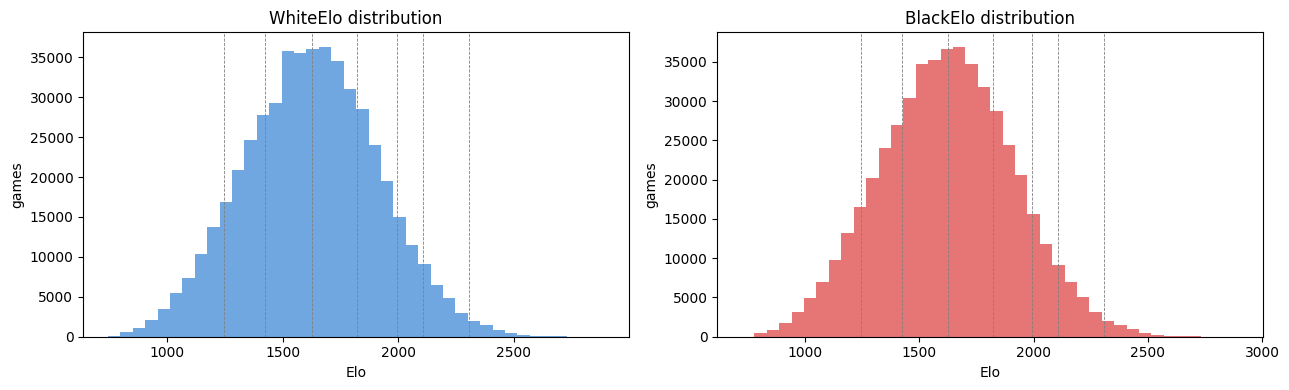

In [8]:
y_white = df['WhiteElo'].values
y_black = df['BlackElo'].values
idx     = np.arange(len(df))

# first hold out test
idx_tv, idx_test = train_test_split(idx, test_size=TEST_SIZE,  random_state=RANDOM_STATE)
# then split remaining into train+val
_val_fraction = VAL_SIZE / (1 - TEST_SIZE)
idx_train, idx_val = train_test_split(idx_tv, test_size=_val_fraction, random_state=RANDOM_STATE)

X_train, X_val, X_test = X_all[idx_train], X_all[idx_val], X_all[idx_test]

print(f'Train: {len(idx_train):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}')
_pct = np.percentile(df_raw['WhiteElo'], [0, 10, 25, 50, 75, 90, 95, 99, 100])
ELO_BINS = sorted(set([int(x) for x in _pct]))
print('ELO_BINS:', ELO_BINS)

weights_white = np.clip(compute_elo_sample_weights(df['WhiteElo'], ELO_BINS), 0, 8.0)
weights_black = np.clip(compute_elo_sample_weights(df['BlackElo'], ELO_BINS), 0, 8.0)

if VERBOSE_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, col, color in zip(axes, ['WhiteElo','BlackElo'], ['#4e91d9','#e05252']):
        ax.hist(df[col], bins=40, color=color, edgecolor='none', alpha=0.8)
        ax.set_title(f'{col} distribution')
        ax.set_xlabel('Elo'); ax.set_ylabel('games')
        for b in ELO_BINS[1:-1]:
            ax.axvline(b, color='gray', lw=0.6, ls='--')
    plt.tight_layout(); plt.show()

## 6 · Hyperparameter search (toggle `RUN_HYPERPARAM_SEARCH`)

In [ ]:
best_params = LGBM_PARAMS.copy()

if LOAD_PRETRAINED_MODELS:
    print('Hyperparam search skipped — using existing pretrained models')
    print('Note: LGBM_PARAMS only used to construct a wrapper model for prediction.')
elif RUN_HYPERPARAM_SEARCH:
    print('Running randomised hyperparam search on White Elo...')
    _base = lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=N_JOBS)
    search = RandomizedSearchCV(
        _base, HYPERPARAM_SEARCH_SPACE,
        n_iter=HYPERPARAM_N_ITER, cv=HYPERPARAM_CV_FOLDS,
        scoring='neg_mean_absolute_error',
        n_jobs=1,          # LGB itself is already parallel
        random_state=RANDOM_STATE, verbose=1,
    )
    search.fit(X_train, y_white[idx_train], sample_weight=weights_white[idx_train])
    best_params.update(search.best_params_)
    print('Best params found:', search.best_params_)
    print(f'Best CV MAE: {-search.best_score_:.1f}')
else:
    print('Hyperparam search skipped — using LGBM_PARAMS from config')
    print('Current params:', best_params)

Hyperparam search skipped — using LGBM_PARAMS from config
Current params: {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'verbose': -1, 'n_jobs': -1}


## 7 · Train

In [ ]:
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')

def _validate_model_path(path: str, label: str) -> str:
    if not path:
        raise ValueError(f'{label} model path is not set.')
    if not os.path.exists(path):
        raise FileNotFoundError(f'{label} model path not found: {path}')
    return path

def load_lgbm_model(model_path: str, params: dict) -> lgb.LGBMRegressor:
    model = lgb.LGBMRegressor(**params)
    model.booster_ = lgb.Booster(model_file=model_path)
    n_feats = model.booster_.num_feature()
    model._n_features = n_feats
    model._n_features_in = n_feats
    return model

def run_experiment(target: str, y_all: np.ndarray, weights: np.ndarray, params: dict) -> dict:
    y_train_ = y_all[idx_train]
    y_val_   = y_all[idx_val]
    y_test_  = y_all[idx_test]
    w_train_ = weights[idx_train]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train_,
        sample_weight=w_train_,
        eval_set=[(X_val, y_val_)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=0)],
    )

    val_preds  = model.predict(X_val)
    test_preds = model.predict(X_test)

    val_mae   = mean_absolute_error(y_val_,  val_preds)
    test_mae  = mean_absolute_error(y_test_, test_preds)
    test_rmse = root_mean_squared_error(y_test_, test_preds)

    print(f'{target}  |  Val MAE: {val_mae:.1f}  |  Test MAE: {test_mae:.1f}  Test RMSE: {test_rmse:.1f}')

    # save model
    fname = f'{MODEL_SAVE_NAME}_{MODEL_SAVE_NOTES}_{target.lower().replace(" ","_")}_{_ts}.txt'
    model.booster_.save_model(fname)
    print(f'  Saved → {fname}')

    return dict(model=model, y_val=y_val_, y_test=y_test_,
                val_preds=val_preds, test_preds=test_preds,
                val_mae=val_mae, test_mae=test_mae, test_rmse=test_rmse,
                label=target)

def run_loaded(target: str, y_all: np.ndarray, model: lgb.LGBMRegressor) -> dict:
    y_val_   = y_all[idx_val]
    y_test_  = y_all[idx_test]

    val_preds  = model.predict(X_val)
    test_preds = model.predict(X_test)

    val_mae   = mean_absolute_error(y_val_,  val_preds)
    test_mae  = mean_absolute_error(y_test_, test_preds)
    test_rmse = root_mean_squared_error(y_test_, test_preds)

    print(f'{target} (loaded)  |  Val MAE: {val_mae:.1f}  |  Test MAE: {test_mae:.1f}  Test RMSE: {test_rmse:.1f}')

    return dict(model=model, y_val=y_val_, y_test=y_test_,
                val_preds=val_preds, test_preds=test_preds,
                val_mae=val_mae, test_mae=test_mae, test_rmse=test_rmse,
                label=target)

if LOAD_PRETRAINED_MODELS:
    white_path = _validate_model_path(PRETRAINED_WHITE_PATH, 'White')
    black_path = _validate_model_path(PRETRAINED_BLACK_PATH, 'Black')

    print(f'Loading pretrained models...')
    print(f'  White: {white_path}')
    print(f'  Black: {black_path}')

    white_model = load_lgbm_model(white_path, best_params)
    black_model = load_lgbm_model(black_path, best_params)

    white_run = run_loaded('WhiteElo', y_white, white_model)
    black_run = run_loaded('BlackElo', y_black, black_model)
else:
    white_run = run_experiment('WhiteElo', y_white, weights_white, best_params)
    black_run = run_experiment('BlackElo', y_black, weights_black, best_params)

c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


WhiteElo  |  Val MAE: 185.6  |  Test MAE: 185.1  Test RMSE: 232.5
  Saved → lgb_elo_500000_alltimes_weightsmax8_2_whiteelo_20260530_170906.txt


c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


BlackElo  |  Val MAE: 187.4  |  Test MAE: 186.8  Test RMSE: 234.5
  Saved → lgb_elo_500000_alltimes_weightsmax8_2_blackelo_20260530_170906.txt


## 8 · Permutation importance

In [ ]:
perm_white = perm_black = None

if RUN_PERM_IMPORTANCE:
    _method = str(FEATURE_IMPORTANCE_METHOD).strip().lower()
    if _method not in ('permutation', 'gain', 'split'):
        print(f'Feature importance skipped — unknown method: {_method}')
    else:
        def compute_importance(run: dict, method: str, n_repeats: int = PERM_N_REPEATS) -> pd.DataFrame:
            if method == 'permutation':
                print(f'Permutation importance — {run["label"]} ({n_repeats} repeats)...')
                t0 = time.time()
                result = permutation_importance(
                    run['model'], X_test, run['y_test'],
                    n_repeats=n_repeats,
                    scoring='neg_mean_absolute_error',
                    n_jobs=N_JOBS,
                    random_state=RANDOM_STATE,
                )
                print(f'  done in {time.time()-t0:.1f}s')
                n = len(feat_names)
                return pd.DataFrame({
                    'feature':    feat_names[:n],
                    'importance': result.importances_mean[:n],
                    'std':        result.importances_std[:n],
                }).sort_values('importance', ascending=False).reset_index(drop=True)

            booster = run['model'].booster_
            importances = booster.feature_importance(importance_type=method)
            n = len(feat_names)
            return pd.DataFrame({
                'feature':    feat_names[:n],
                'importance': importances[:n],
                'std':        np.zeros(n, dtype=float),
            }).sort_values('importance', ascending=False).reset_index(drop=True)

        perm_white = compute_importance(white_run, _method)
        perm_black = compute_importance(black_run, _method)

        if VERBOSE_PLOTS:
            if _method == 'permutation':
                _xlabel = 'MAE decrease when shuffled'
                _title_suffix = 'Permutation importance'
            elif _method == 'gain':
                _xlabel = 'Total gain'
                _title_suffix = 'LightGBM gain importance'
            else:
                _xlabel = 'Split count'
                _title_suffix = 'LightGBM split importance'

            fig, axes = plt.subplots(1, 2, figsize=(16, 8))
            for ax, perm, title in zip(axes,
                                       [perm_white, perm_black],
                                       ['White Elo', 'Black Elo']):
                top = perm.head(TOP_N_FEATURES).iloc[::-1]
                ax.barh(top['feature'], top['importance'], xerr=top['std'],
                        color='#4e91d9', ecolor='#333', capsize=3, alpha=0.85)
                ax.axvline(0, color='black', lw=0.8)
                ax.set_title(f'{_title_suffix} — {title}')
                ax.set_xlabel(_xlabel)
            plt.tight_layout(); plt.show()

            # side-by-side top features
            merged = (
                perm_white.head(TOP_N_FEATURES).rename(columns={'importance':'white'})
                .merge(perm_black.rename(columns={'importance':'black'}), on='feature', how='outer')
                .fillna(0).set_index('feature')[['white','black']]
                .sort_values('white', ascending=True)
            )
            fig, ax = plt.subplots(figsize=(10, 7))
            x = np.arange(len(merged)); bw = 0.4
            ax.barh(x-bw/2, merged['white'], bw, label='White', color='#4e91d9', alpha=0.85)
            ax.barh(x+bw/2, merged['black'], bw, label='Black', color='#e05252', alpha=0.85)
            ax.set_yticks(x); ax.set_yticklabels(merged.index)
            ax.set_xlabel(_xlabel); ax.set_title('Top features: White vs Black')
            ax.legend(); plt.tight_layout(); plt.show()
else:
    print('Feature importance skipped (RUN_PERM_IMPORTANCE=False)')

Permutation importance — WhiteElo (5 repeats)...


c:\Users\villa\Desktop\AppML26\appMLenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 9 · Retrain on top-N features (toggle `RETRAIN_TOP_N`)

In [ ]:
if RETRAIN_TOP_N and perm_white is not None:
    top_feats = perm_white.head(TOP_N_FEATURES)['feature'].tolist()
    print(f'Retraining on top {TOP_N_FEATURES} features: {top_feats}')

    # Rebuild matrix with only top features
    _top_idx  = [feat_names.index(f) for f in top_feats if f in feat_names]
    X_top     = X_all[:, _top_idx]
    X_tr_top  = X_top[idx_train]
    X_v_top   = X_top[idx_val]
    X_te_top  = X_top[idx_test]

    def run_top(target, y_all, weights, color):
        model = lgb.LGBMRegressor(**best_params)
        model.fit(X_tr_top, y_all[idx_train],
                  sample_weight=weights[idx_train],
                  eval_set=[(X_v_top, y_all[idx_val])],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(period=0)])
        preds    = model.predict(X_te_top)
        test_mae = mean_absolute_error(y_all[idx_test], preds)
        test_rmse= root_mean_squared_error(y_all[idx_test], preds)
        fname    = f'{MODEL_SAVE_NAME}_{target.lower()}_top{TOP_N_FEATURES}_{_ts}.txt'
        model.booster_.save_model(fname)
        print(f'{target} (top-{TOP_N_FEATURES})  |  Test MAE: {test_mae:.1f}  RMSE: {test_rmse:.1f}  → {fname}')
        return preds, y_all[idx_test], test_mae

    w_preds_top, w_true_top, w_mae_top = run_top('WhiteElo', y_white, weights_white, '#4e91d9')
    b_preds_top, b_true_top, b_mae_top = run_top('BlackElo', y_black, weights_black, '#e05252')
else:
    if not RETRAIN_TOP_N:
        print('Top-N retrain skipped (RETRAIN_TOP_N=False)')
    else:
        print('Top-N retrain skipped — run feature importance first')

Top-N retrain skipped (RETRAIN_TOP_N=False)


## 10 · Results & diagnostic plots

In [ ]:
# ── summary table ─────────────────────────────────────────────────────────────
rows = [
    {'model': 'Full — White', 'Val MAE': white_run['val_mae'],
     'Test MAE': white_run['test_mae'], 'Test RMSE': white_run['test_rmse']},
    {'model': 'Full — Black', 'Val MAE': black_run['val_mae'],
     'Test MAE': black_run['test_mae'], 'Test RMSE': black_run['test_rmse']},
]
if RETRAIN_TOP_N and perm_white is not None:
    rows += [
        {'model': f'Top-{TOP_N_FEATURES} — White', 'Val MAE': None,
         'Test MAE': w_mae_top, 'Test RMSE': None},
        {'model': f'Top-{TOP_N_FEATURES} — Black', 'Val MAE': None,
         'Test MAE': b_mae_top, 'Test RMSE': None},
    ]
pd.DataFrame(rows).round(2)

,model,Val MAE,Test MAE,Test RMSE
0,Full — White,182.02,179.53,224.89
1,Full — Black,179.88,178.40,223.86


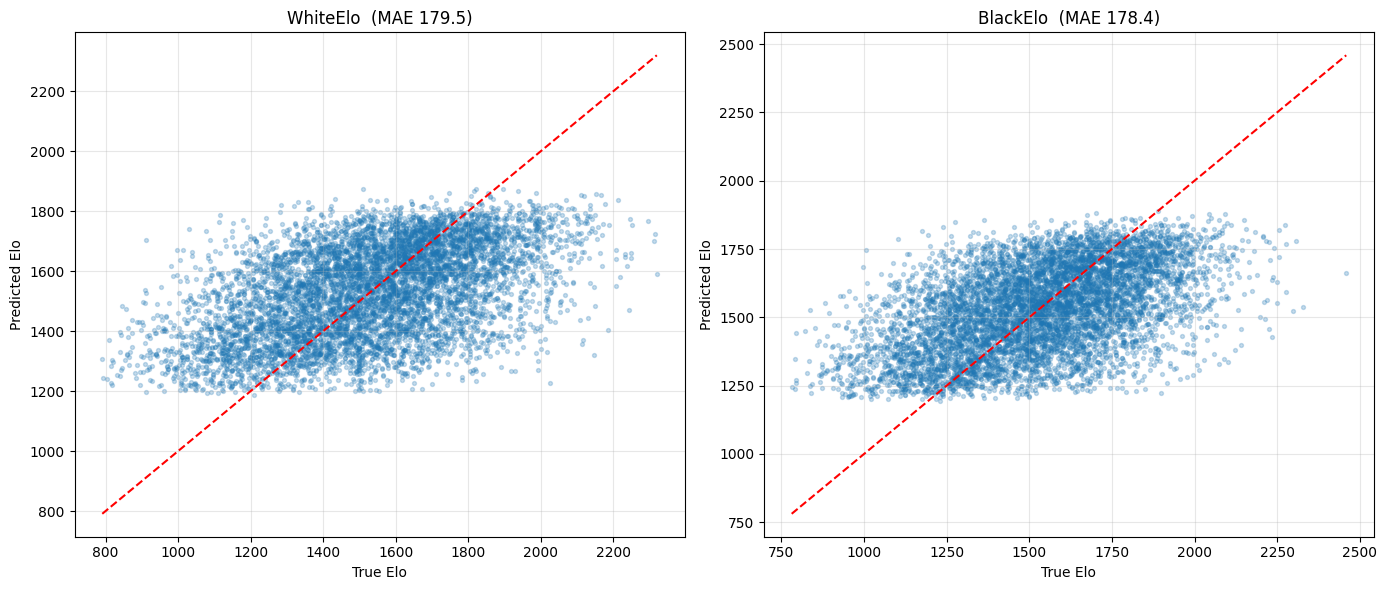

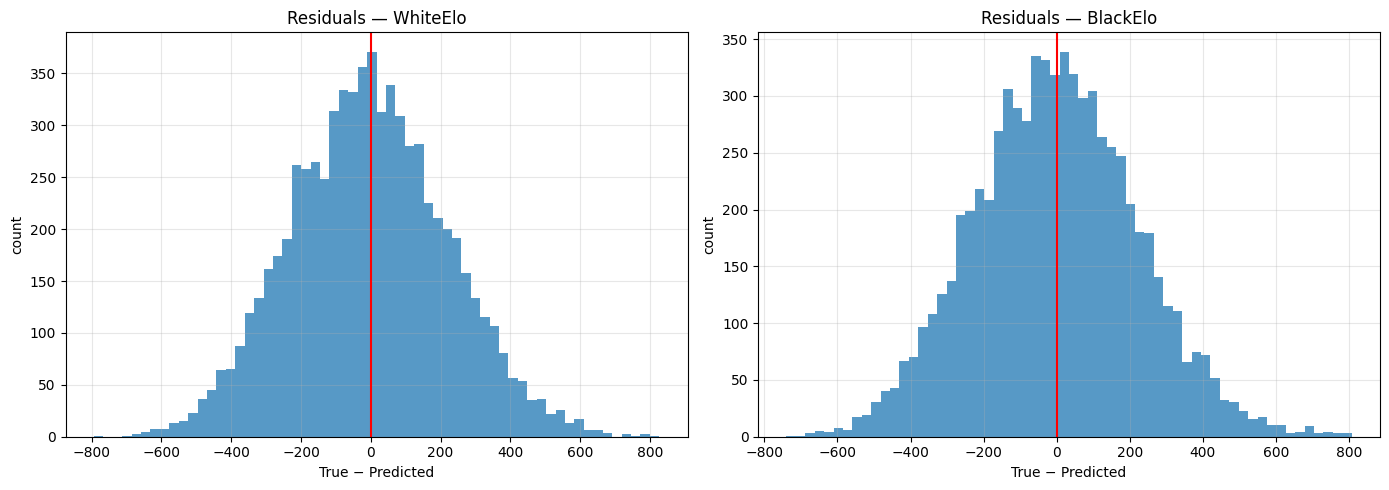

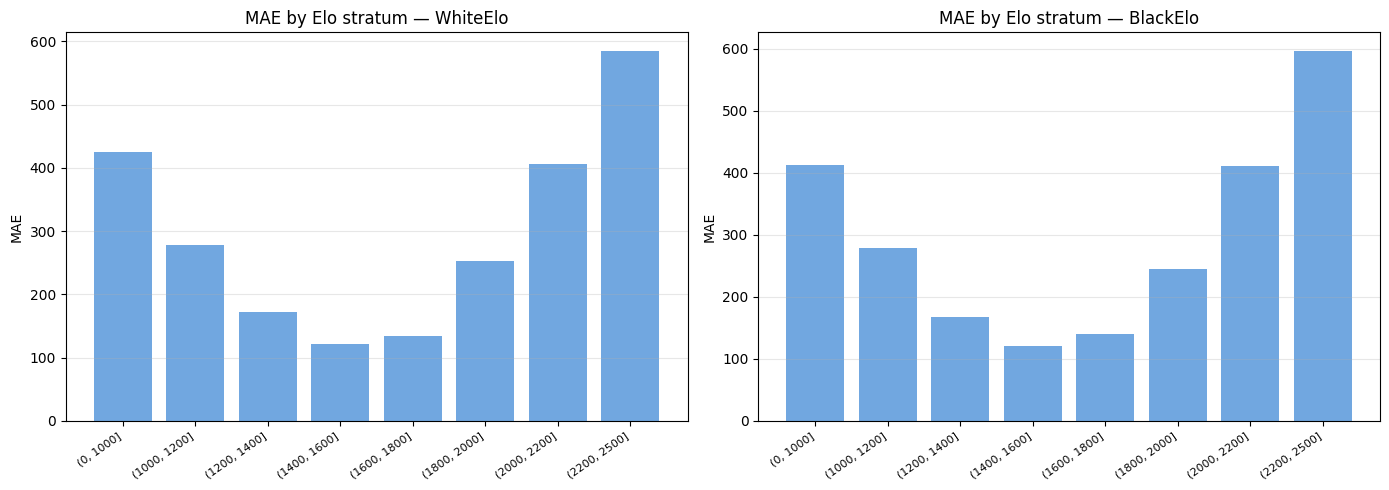

In [ ]:
if VERBOSE_PLOTS:
    # True vs predicted
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, run in zip(axes, [white_run, black_run]):
        y_t, y_p = run['y_test'], run['test_preds']
        lo, hi = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
        ax.scatter(y_t, y_p, alpha=0.25, s=8, rasterized=True)
        ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
        ax.set_xlabel('True Elo'); ax.set_ylabel('Predicted Elo')
        ax.set_title(f"{run['label']}  (MAE {run['test_mae']:.1f})")
        ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # Residuals
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, run in zip(axes, [white_run, black_run]):
        res = run['y_test'] - run['test_preds']
        ax.hist(res, bins=60, edgecolor='none', alpha=0.75)
        ax.axvline(0, color='red', lw=1.5)
        ax.set_title(f"Residuals — {run['label']}")
        ax.set_xlabel('True − Predicted'); ax.set_ylabel('count')
        ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # MAE by Elo stratum
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, run, elo_col in zip(axes, [white_run, black_run],
                                 ['WhiteElo', 'BlackElo']):
        true_elo  = df[elo_col].values[idx_test]
        strata    = pd.cut(true_elo, bins=ELO_BINS)
        mae_s     = pd.Series(np.abs(run['y_test'] - run['test_preds'])) \
                      .groupby(strata, observed=True).mean()
        ax.bar(range(len(mae_s)), mae_s.values, color='#4e91d9', alpha=0.8)
        ax.set_xticks(range(len(mae_s)))
        ax.set_xticklabels([str(b) for b in mae_s.index], rotation=35, ha='right', fontsize=8)
        ax.set_ylabel('MAE')
        ax.set_title(f"MAE by Elo stratum — {run['label']}")
        ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()